In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [48]:
df = pd.read_csv('heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [49]:
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset Shape: 303 rows and 14 columns


In [50]:
print("Missing values in each column:")

print(df.isnull().sum())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


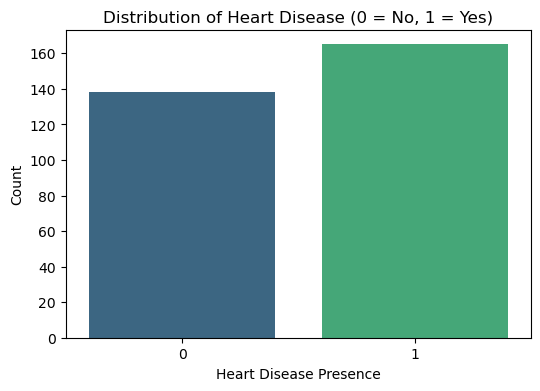

In [51]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution of Heart Disease (0 = No, 1 = Yes)')
plt.xlabel('Heart Disease Presence')
plt.ylabel('Count')
plt.show()

In [52]:

X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [53]:
# Feature Scaling: Logistic regression performs better when features are on the same scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (242, 13)
Testing features shape: (61, 13)


In [54]:
log_reg_model = LogisticRegression()
log_reg_model.fit(X_train_scaled, y_train)


LogisticRegression()

In [55]:
# Make predictions on the testing set
y_pred = log_reg_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 80.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



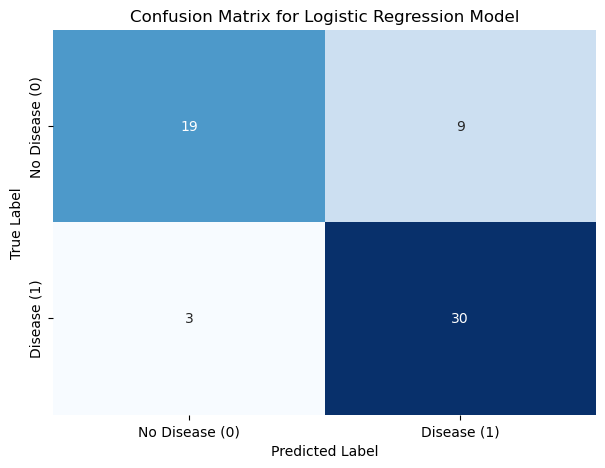

In [56]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease (0)', 'Disease (1)'],
            yticklabels=['No Disease (0)', 'Disease (1)'])
plt.title('Confusion Matrix for Logistic Regression Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [83]:
import numpy as np

# [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]
new_patient = np.array([[52, 1, 2, 120, 10, 0, 1, 147, 0, 0.4, 1, 0, 3]])

# Convert it to a DataFrame with the same column names as the original dataset
new_patient_df = pd.DataFrame(new_patient, columns=X.columns)

# Scale the new data using the ALREADY FITTED scaler
new_patient_scaled = scaler.transform(new_patient_df)

# Make the prediction
prediction = log_reg_model.predict(new_patient_scaled)
probability = log_reg_model.predict_proba(new_patient_scaled)

print("--- Prediction Results ---")
if prediction[0] == 1:
    print("Diagnosis: The model predicts the PRESENCE of heart disease.")
else:
    print("Diagnosis: The model predicts the ABSENCE of heart disease.")

print(f"Confidence (Probability of No Disease): {probability[0][0]*100:.2f}%")
print(f"Confidence (Probability of Disease): {probability[0][1]*100:.2f}%")

--- Prediction Results ---
Diagnosis: The model predicts the PRESENCE of heart disease.
Confidence (Probability of No Disease): 3.36%
Confidence (Probability of Disease): 96.64%
